In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pymongo import MongoClient
import numpy as np
from matplotlib.dates import DateFormatter
import warnings
warnings.filterwarnings('ignore')


In [2]:
client = MongoClient('mongodb://localhost:27017/')

db = client["Retali_Business"]

orders_col = db["Orders"]

In [3]:
top_customers_pipeline = [
        {
            "$group": {
                "_id": "$customer.id",
                "customerName": {"$first": "$customer.name"},
                "totalSpent": {"$sum": "$sale.total_amount"},
                "transactionCount": {"$sum": 1}
            }
        },
        {"$sort": {"totalSpent": -1}},
        {"$limit": 10}
    ]

best_selling_products_pipeline = [
        {
            "$group": {
                "_id": "$product.id",
                "productName": {"$first": "$product.name"},
                "category": {"$first": "$product.category"},
                "totalQuantity": {"$sum": "$product.quantity"},
                "totalRevenue": {"$sum": {"$multiply": ["$product.price", "$product.quantity"]}}
            }
        },
        {"$sort": {"totalQuantity": -1}},
        {"$limit": 10}
    ]

best_selling_products_by_branch_pipeline = [
    {
            "$group": {
                "_id": {
                    "branchId": "$branch.id",
                    "branchName": "$branch.name",
                    "productId": "$product.id",
                    "productName": "$product.name"
                },
                "totalQuantity": {"$sum": "$product.quantity"}
            }
        },
        {"$sort": {"_id.branchId": 1, "totalQuantity": -1}}
]

branch_comparisons_pipeline = [
    {
            "$group": {
                "_id": "$branch.id",
                "branchName": {"$first": "$branch.name"},
                "city": {"$first": "$branch.city"},
                "totalRevenue": {"$sum": "$sale.total_amount"},
                "transactionCount": {"$sum": 1},
                "avgTransaction": {"$avg": "$sale.total_amount"}
            }
        },
        {"$sort": {"totalRevenue": -1}},
        {"$limit": 10}
]

time_analysis_pipeline = [
    {
            "$addFields": {
                "yearMonth": {"$substr": ["$sale.date", 0, 7]}
            }
        },
        {
            "$group": {
                "_id": "$yearMonth",
                "totalRevenue": {"$sum": "$sale.total_amount"},
                "transactionCount": {"$sum": 1},
                "avgTransaction": {"$avg": "$sale.total_amount"}
            }
        },
        {"$sort": {"_id": 1}}
        ]

seasonal_demand_pipeline = [
    {
            "$addFields": {
                "month": {"$substr": ["$sale.date", 5, 2]},
                "category": "$product.category"
            }
        },
        {
            "$group": {
                "_id": {
                    "month": "$month",
                    "category": "$category"
                },
                "totalQuantity": {"$sum": "$product.quantity"}
            }
        },
        {"$sort": {"_id.month": 1, "totalQuantity": -1}}
        ]

stock_planning_pipeline = [
     {
            "$group": {
                "_id": {
                    "branchId": "$branch.id",
                    "branchName": "$branch.name",
                    "productId": "$product.id",
                    "productName": "$product.name",
                    "category": "$product.category"
                },
                "totalSold": {"$sum": "$product.quantity"},
                "totalRevenue": {"$sum": "$sale.total_amount"},
                "avgPrice": {"$avg": "$product.price"}
            }
        },
        {"$sort": {"totalSold": -1}}
        ]

In [5]:
def get_query(pipeline):
    try:
        data = list(orders_col.aggregate(pipeline))
        return True, data

    except Exception as e:
        return False, str(e)

In [ ]:
def get_data(filter={}):
    try:
        data = []
        for doc in orders_col.find(filter):
            doc['_id'] = str(doc['_id'])
            data.append(doc)
        return True, data

    except Exception as e:
        return False, str(e)

In [4]:
def top_customers_analysis(pipeline = top_customers_pipeline):
    
    
    results = list(orders_col.aggregate(pipeline))
    df = pd.DataFrame(results)
    
    # Create visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Horizontal bar chart
    df_sorted = df.sort_values('totalSpent')
    ax1.barh(df_sorted['customerName'], df_sorted['totalSpent'])
    ax1.set_xlabel('Total Spent ($)')
    ax1.set_title('Top 10 Customers by Spending')
    ax1.grid(True, alpha=0.3)
    
    # Scatter plot: Transactions vs Spending
    ax2.scatter(df['transactionCount'], df['totalSpent'], s=100, alpha=0.7)
    ax2.set_xlabel('Number of Transactions')
    ax2.set_ylabel('Total Spent ($)')
    ax2.set_title('Transactions vs Spending')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return df

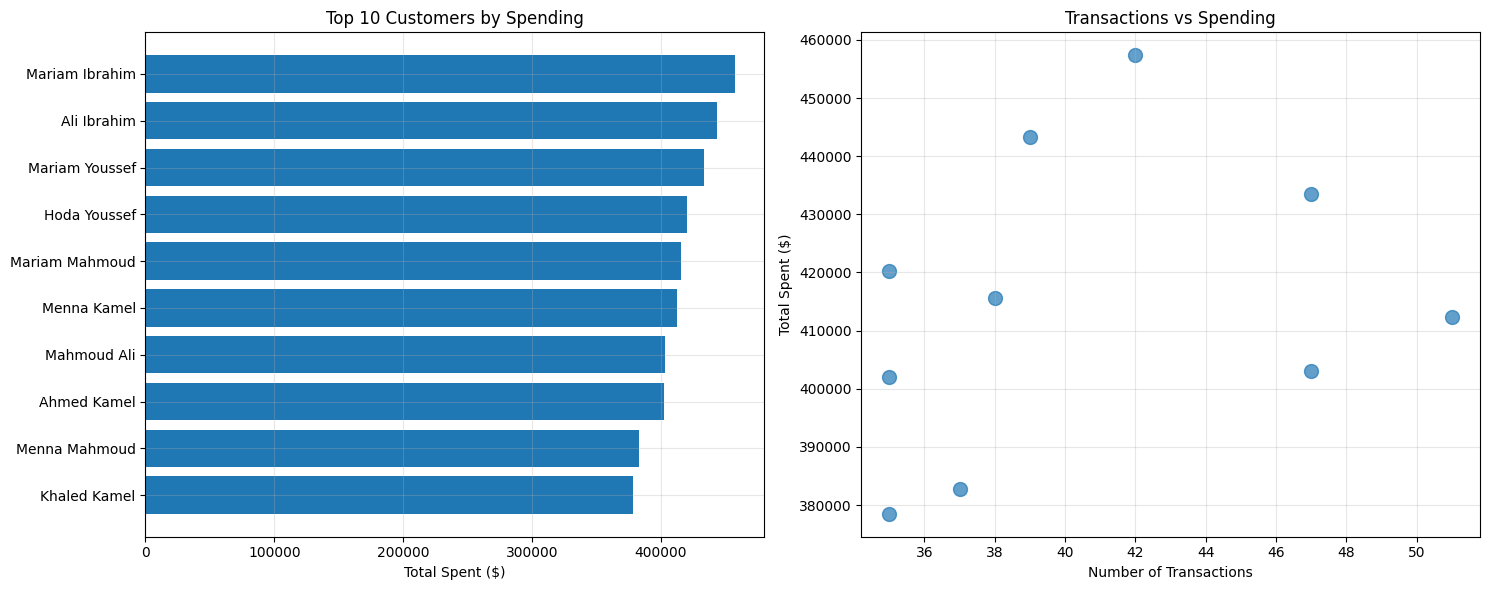

,_id,customerName,totalSpent,transactionCount
0,12399,Mariam Ibrahim,457363.16,42
1,5042,Ali Ibrahim,443270.87,39
2,8636,Mariam Youssef,433441.19,47
3,3051,Hoda Youssef,420328.42,35
4,7287,Mariam Mahmoud,415659.87,38
5,237,Menna Kamel,412337.63,51
6,10715,Mahmoud Ali,403088.00,47
7,7664,Ahmed Kamel,402106.78,35
8,17491,Menna Mahmoud,382787.61,37
9,10099,Khaled Kamel,378493.29,35


In [5]:
top_customers_analysis()

In [11]:
def best_selling_products(pipeline=best_selling_products_pipeline):
    
    results = list(orders_col.aggregate(pipeline))
    df = pd.DataFrame(results)
    
    # Visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Bar chart for quantities
    colors = plt.cm.Set3(np.linspace(0, 1, len(df)))
    ax1.bar(df['productName'], df['totalQuantity'], color=colors)
    ax1.set_xticklabels(df['productName'], rotation=45, ha='right')
    ax1.set_ylabel('Quantity Sold')
    ax1.set_title('Top 10 Best-Selling Products')
    
    # Revenue breakdown by category
    if 'category' in df.columns:
        category_revenue = df.groupby('category')['totalRevenue'].sum()
        wedges, texts, autotexts = ax2.pie(category_revenue, 
                                          labels=category_revenue.index,
                                          autopct='%1.1f%%',
                                          startangle=90)
        ax2.set_title('Revenue Distribution by Category')
    
    plt.tight_layout()
    plt.show()
    
    return df

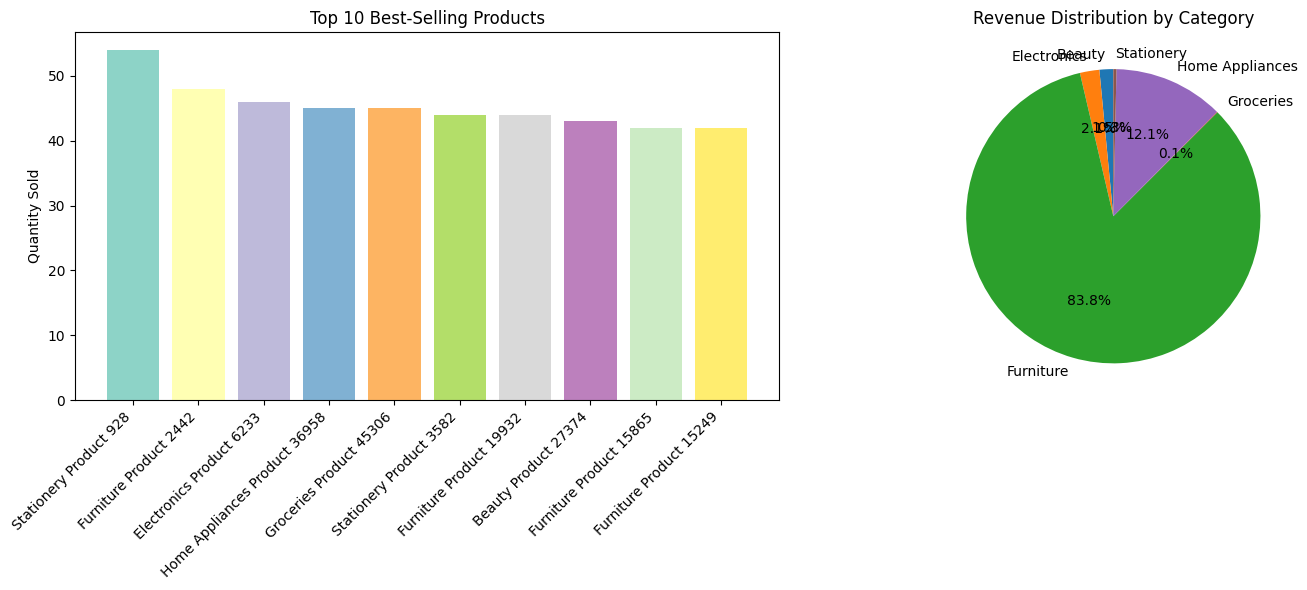

,_id,productName,category,totalQuantity,totalRevenue
0,928,Stationery Product 928,Stationery,54,14375.88
1,2442,Furniture Product 2442,Furniture,48,1605385.44
2,6233,Electronics Product 6233,Electronics,46,147698.18
3,36958,Home Appliances Product 36958,Home Appliances,45,836026.65
4,45306,Groceries Product 45306,Groceries,45,4279.50
5,3582,Stationery Product 3582,Stationery,44,9717.40
6,19932,Furniture Product 19932,Furniture,44,2007368.00
7,27374,Beauty Product 27374,Beauty,43,104543.75
8,15865,Furniture Product 15865,Furniture,42,744341.64
9,15249,Furniture Product 15249,Furniture,42,1439040.54


In [12]:
best_selling_products()

In [4]:
results = list(orders_col.aggregate(best_selling_products_by_branch_pipeline))

In [8]:
def products_by_branch(pipeline=best_selling_products_by_branch_pipeline):
    
    
    results = list(orders_col.aggregate(pipeline))
    
    # Process data for grouped bar chart
    data = []
    for r in results:
        data.append({
            'branch': r['_id']['branchName'],
            'product': r['_id']['productName'],
            'quantity': r['totalQuantity']
        })
    
    df = pd.DataFrame(data)
    
    # Get top 5 products per branch
    top_products_by_branch = df.groupby('branch').apply(
        lambda x: x.nlargest(5, 'quantity')
    ).reset_index(drop=True)
    
    # Pivot for grouped bar chart
    pivot_df = top_products_by_branch.pivot(
        index='product',
        columns='branch',
        values='quantity'
    ).fillna(0)
    
    # Visualization
    fig, ax = plt.subplots(figsize=(12, 8))
    pivot_df.plot(kind='bar', ax=ax, width=0.8)
    ax.set_xlabel('Product')
    ax.set_ylabel('Quantity Sold')
    ax.set_title('Best-Selling Products by Branch (Top 5 per Branch)')
    ax.legend(title='Branch')
    ax.grid(True, alpha=0.3)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    
    return df


In [10]:
def branch_comparisons(pipeline=branch_comparisons_pipeline):
    
    results = list(orders_col.aggregate(pipeline))
    df = pd.DataFrame(results)
    
    # Visualization
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # Revenue bar chart
    df_sorted = df.sort_values('totalRevenue')
    axes[0,0].barh(df_sorted['branchName'], df_sorted['totalRevenue'])
    axes[0,0].set_xlabel('Total Revenue ($)')
    axes[0,0].set_title('Branch Revenue Comparison')
    
    # Transactions bar chart
    axes[0,1].bar(df['branchName'], df['transactionCount'])
    axes[0,1].set_xticklabels(df['branchName'], rotation=45, ha='right')
    axes[0,1].set_ylabel('Number of Transactions')
    axes[0,1].set_title('Transaction Count by Branch')
    
    # Avg transaction value
    axes[1,0].bar(df['branchName'], df['avgTransaction'])
    axes[1,0].set_xticklabels(df['branchName'], rotation=45, ha='right')
    axes[1,0].set_ylabel('Average Transaction Value ($)')
    axes[1,0].set_title('Average Transaction Value by Branch')
    
    # Revenue vs Transactions scatter
    axes[1,1].scatter(df['transactionCount'], df['totalRevenue'], s=200, alpha=0.7)
    for i, row in df.iterrows():
        axes[1,1].annotate(row['branchName'], 
                          (row['transactionCount'], row['totalRevenue']),
                          fontsize=8)
    axes[1,1].set_xlabel('Transaction Count')
    axes[1,1].set_ylabel('Total Revenue ($)')
    axes[1,1].set_title('Transactions vs Revenue')
    axes[1,1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return df

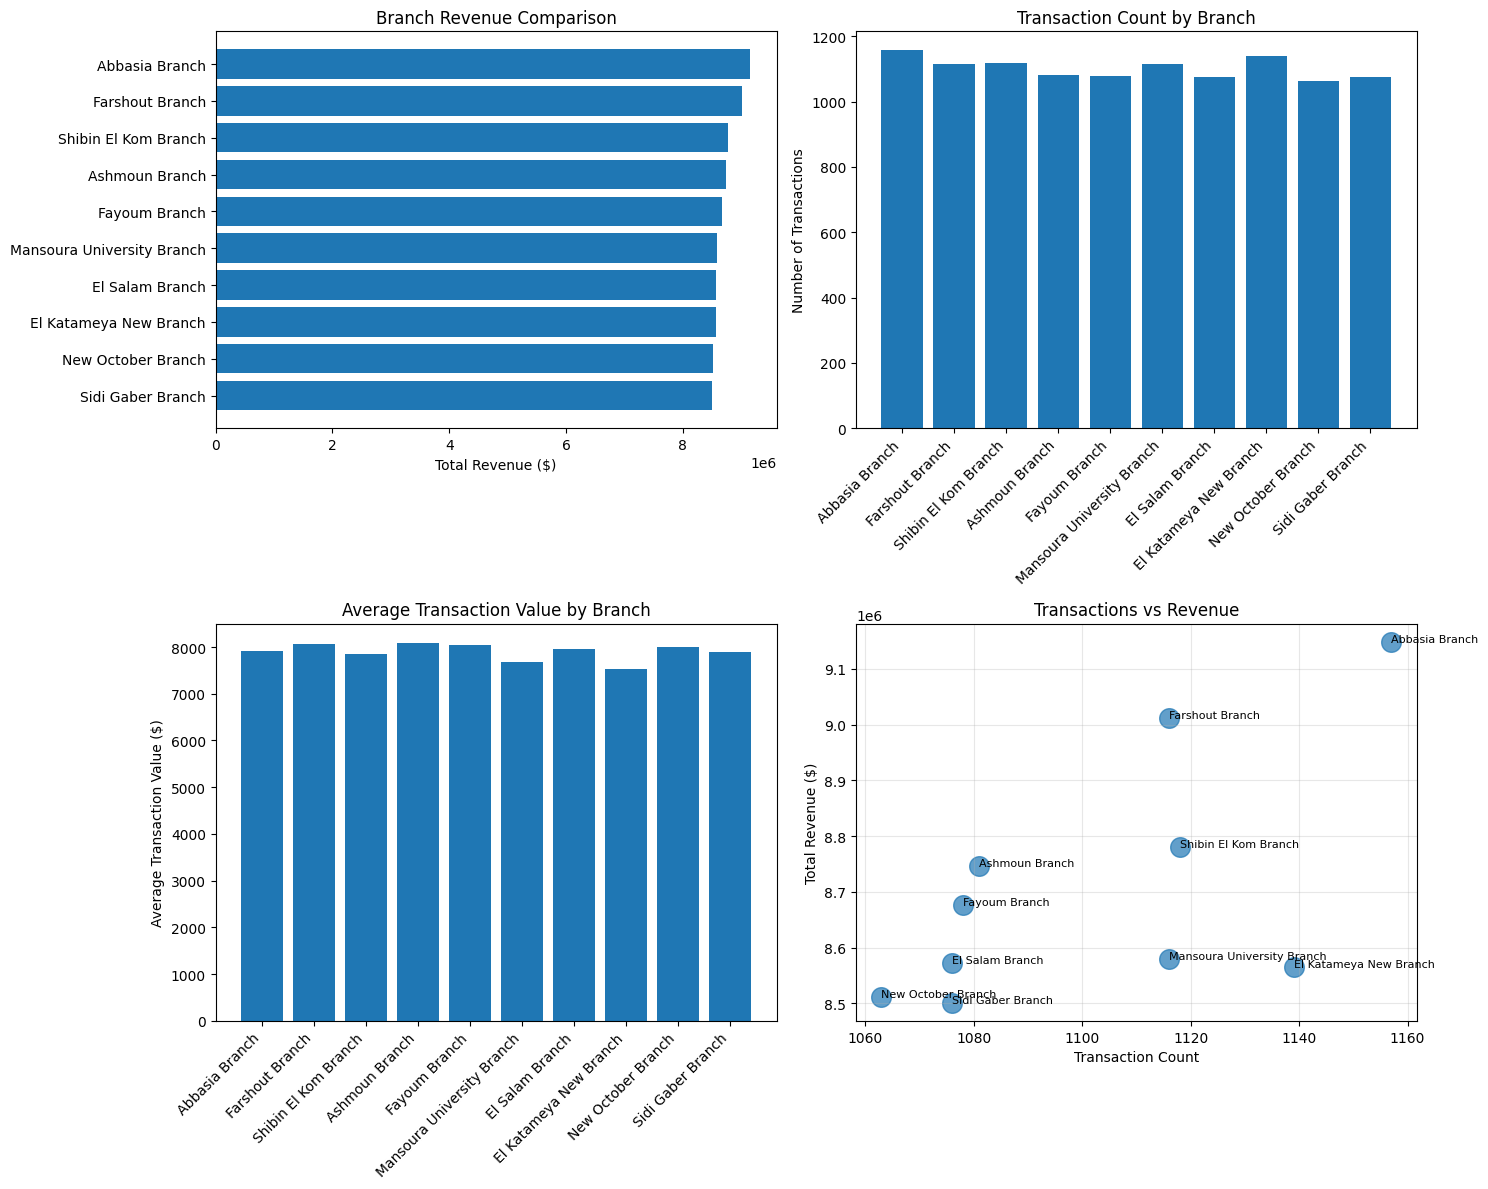

,_id,branchName,city,totalRevenue,transactionCount,avgTransaction
0,27,Abbasia Branch,Cairo,9148565.04,1157,7907.143509
1,96,Farshout Branch,Luxor,9012150.04,1116,8075.403262
2,66,Shibin El Kom Branch,Tanta,8779901.01,1118,7853.220939
3,67,Ashmoun Branch,Tanta,8747262.61,1081,8091.824801
4,51,Fayoum Branch,Giza,8677125.58,1078,8049.281614
5,129,Mansoura University Branch,Mansoura,8579457.57,1116,7687.685995
6,72,El Salam Branch,Cairo,8572216.52,1076,7966.743978
7,143,El Katameya New Branch,Cairo,8564774.91,1139,7519.556550
8,159,New October Branch,Giza,8510760.75,1063,8006.360066
9,11,Sidi Gaber Branch,Alexandria,8500979.21,1076,7900.538299


In [11]:
branch_comparisons()

In [4]:
def time_analysis(pipeline=time_analysis_pipeline):
    
    results = list(orders_col.aggregate(pipeline))
    df = pd.DataFrame(results)
    df['_id'] = pd.to_datetime(df['_id'] + '-01')
    df = df.sort_values('_id')
    
    # Visualization
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Line chart - Revenue trend
    axes[0,0].plot(df['_id'], df['totalRevenue'], marker='o', linewidth=2)
    axes[0,0].set_xlabel('Month')
    axes[0,0].set_ylabel('Revenue ($)')
    axes[0,0].set_title('Monthly Revenue Trend')
    axes[0,0].grid(True, alpha=0.3)
    
    # Line chart - Transaction count trend
    axes[0,1].plot(df['_id'], df['transactionCount'], marker='s', linewidth=2, color='orange')
    axes[0,1].set_xlabel('Month')
    axes[0,1].set_ylabel('Transaction Count')
    axes[0,1].set_title('Monthly Transaction Trend')
    axes[0,1].grid(True, alpha=0.3)
    
    # Line chart - Average transaction value
    axes[1,0].plot(df['_id'], df['avgTransaction'], marker='^', linewidth=2, color='green')
    axes[1,0].set_xlabel('Month')
    axes[1,0].set_ylabel('Average Transaction ($)')
    axes[1,0].set_title('Average Transaction Value Trend')
    axes[1,0].grid(True, alpha=0.3)
    
    # Seasonal decomposition (simplified)
    if len(df) >= 12:
        df['month'] = df['_id'].dt.month
        monthly_avg = df.groupby('month')['totalRevenue'].mean()
        axes[1,1].bar(monthly_avg.index, monthly_avg.values)
        axes[1,1].set_xlabel('Month')
        axes[1,1].set_ylabel('Average Revenue ($)')
        axes[1,1].set_title('Seasonal Pattern (Average by Month)')
        axes[1,1].set_xticks(range(1, 13))
    
    plt.tight_layout()
    plt.show()
    
    return df


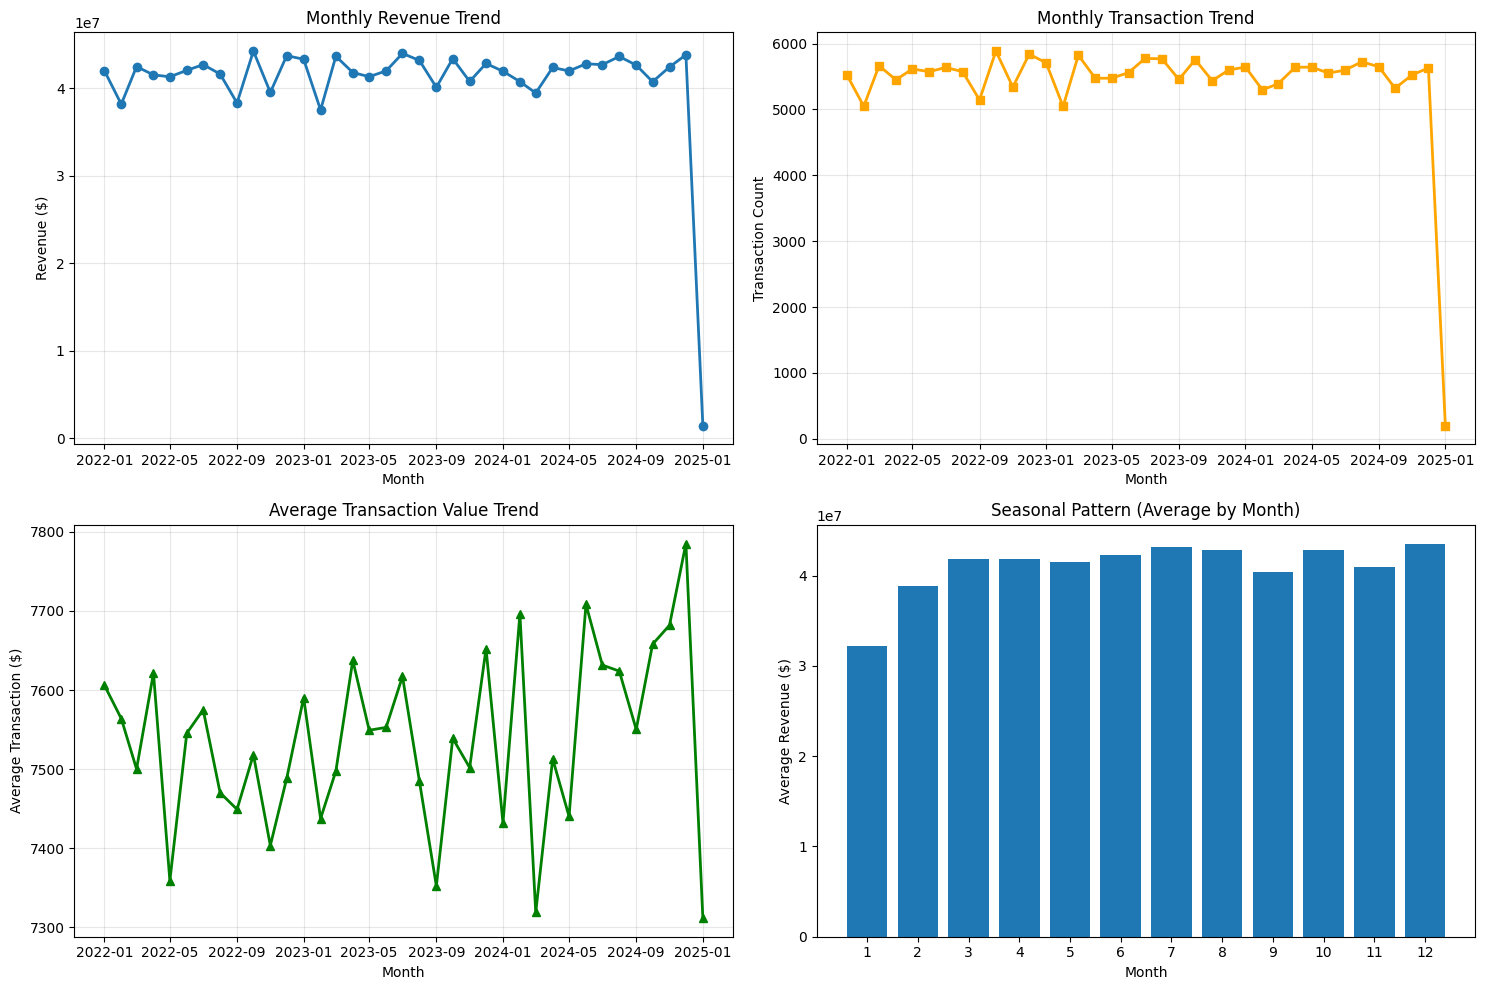

,_id,totalRevenue,transactionCount,avgTransaction,month
0,2022-01-01,42032212.94,5526,7606.263652,1
1,2022-02-01,38190615.09,5049,7563.995859,2
2,2022-03-01,42480935.94,5664,7500.165244,3
3,2022-04-01,41537095.05,5450,7621.485330,4
4,2022-05-01,41320485.14,5615,7358.946597,5
5,2022-06-01,42058371.85,5574,7545.456019,6
6,2022-07-01,42708046.54,5638,7575.034860,7
7,2022-08-01,41638950.41,5574,7470.209977,8
8,2022-09-01,38326013.88,5145,7449.176653,9
9,2022-10-01,44260405.67,5887,7518.329484,10


In [5]:
time_analysis()